In [1]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor


In [2]:
breast = pd.read_csv('breast-level_annotations.csv')
columns = ['study_id','series_id', 'laterality', 'view_position',
       'breast_birads', 'breast_density']
breast = breast[columns]
breast['breast_density'] = breast['breast_density'].map({'DENSITY A':1 , 'DENSITY B': 2 , 'DENSITY C' : 3 , 'DENSITY D': 4})

# Convert BI-RADS to numeric (int)
breast['breast_birads'] = (
    breast['breast_birads']
    .str.replace('BI-RADS ', '', regex=False)  # Remove prefix
    .astype(int)  # Convert to integer
)

# Collapse to breast-level (one row per study_id + laterality)
breast = breast.groupby(['study_id','series_id', 'laterality'], as_index=False).agg({
    'breast_birads': 'max',
    'breast_density': 'max'
})

breast.head()

,study_id,series_id,laterality,breast_birads,breast_density
0,0025a5dc99fd5c742026f0b2b030d3e9,47d59b788d64eecab165d97471c4131a,L,1,3
1,0025a5dc99fd5c742026f0b2b030d3e9,47d59b788d64eecab165d97471c4131a,R,1,3
2,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,ff5d6ba6e303628092020e897fcbc9b1,L,2,3
3,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,ff5d6ba6e303628092020e897fcbc9b1,R,2,3
4,0034765af074f93ed33d5e8399355caf,91de7075b7eb54cc4fc959ef67b9df56,L,2,3


In [3]:
find=pd.read_csv('finding_annotations.csv')
find.head()
columns = ['study_id', 'series_id', 'laterality', 
        'breast_birads', 'breast_density', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax']
find = find[columns]

# birads to int
find['breast_birads'] = (
    find['breast_birads']
    .str.replace('BI-RADS ', '', regex=False)  # Remove prefix
    .astype(float)  # Convert to integer
)
find['finding_birads'] = (
    find['finding_birads']
    .str.replace('BI-RADS ', '', regex=False)
    .astype(float)
)

# casting to int
find['breast_density'] = find['breast_density'].map({'DENSITY A':1 , 'DENSITY B': 2 , 'DENSITY C' : 3 , 'DENSITY D': 4})


# 2. Calculate lesion size
find['width']  = find['xmax'] - find['xmin']
find['height'] = find['ymax'] - find['ymin']
find['area']   = find['width'] * find['height']


# Aggregate to breast-level
find = (
    find.groupby(['study_id','series_id', 'laterality'], as_index=False)
        .agg(
            breast_birads=('breast_birads', 'max'),          # highest BI-RADS across views
            breast_density=('breast_density', 'max'),        # highest density across views
            findings_count=('finding_birads', lambda x: x.notna().sum()),  # count only valid findings
            mean_width=('width', 'mean'),
            max_width=('width', 'max'),
            mean_height=('height', 'mean'),
            max_height=('height', 'max'),
            mean_area=('area', 'mean'),
            max_area=('area', 'max')
        )
)

print(find.shape)
find.head()


(978, 12)


,study_id,series_id,laterality,breast_birads,breast_density,findings_count,mean_width,max_width,mean_height,max_height,mean_area,max_area
0,003700f3c960e0b9bca2b8437c3dbf05,a729825009af3184f46ef773e3d93d87,L,4.0,3.0,2,59.369019,60.053009,58.139954,65.059937,3456.445210,3907.044982
1,008b8e61390fcb4c0873258c15b0a53a,bd0e137f3fc5b069db934797924d7d99,R,4.0,3.0,2,424.325073,443.100098,467.834472,476.609008,198678.638727,211185.498374
2,00a369b4ec1e5e0ff34e6bd838e5f2d6,0da08b11f65b222c697727fd32ab068e,L,3.0,3.0,1,288.879990,288.879990,325.830079,325.830079,94125.789833,94125.789833
3,012e0595adba5173b6e60a97f9e84b6e,a80a25f4bb029ba92a3ae1c6babcc767,L,3.0,3.0,2,428.645996,443.984009,523.434998,568.439942,225058.602514,252378.244211
4,012e0595adba5173b6e60a97f9e84b6e,a80a25f4bb029ba92a3ae1c6babcc767,R,3.0,3.0,2,374.260010,376.979980,422.390075,444.460083,158023.683900,165134.716572


In [4]:
meta = pd.read_csv('metadata.csv')
meta = meta.rename(columns={
    "Series Instance UID": "series_id",
    "Patient's Age": "age"
})

In [ ]:
# Merge on study_id + laterality
df = pd.merge(breast, find, on=['study_id', 'laterality'], how='inner')

meta_agg = meta.groupby('series_id', as_index=False)['age'].max()
df = pd.merge(df, meta_agg, left_on='series_id_x', right_on='series_id', how='left')






# Check shape and sample
print("Merged shape:", df.shape)
# Map laterality: L -> 0, R -> 1
df['laterality'] = df['laterality'].map({'L': 0, 'R': 1})

df = df.drop(columns=['study_id', 'breast_birads_y','breast_density_y'])
df = df.rename(columns={
     'breast_birads_x': 'breast_birads',
    'breast_density_x': 'breast_density'
})
# Merge BI-RADS 2 into BI-RADS 3, then re-map
df['breast_birads'] = df['breast_birads'].replace({2: 3})
df['breast_birads'] = df['breast_birads'].replace({4: 5})
# as only 8 cases ofbirads 2
df['breast_birads'] = df['breast_birads'].map({3:0,5:1})

# ---------------------------------------------------------
# Remove trailing 'Y', leading zeros, and convert to numeric
df['age'] = pd.to_numeric(
    df['age'].astype(str).str.rstrip('Y').str.lstrip('0'),
    errors='coerce'
)

# Now drop rows with NaN ages
df = df.dropna(subset=['age'])

# Now it's safe: convert to int
df['age'] = df['age'].astype(int)


#-----------------------------------------------------------

# 4. Basic ratios & per-finding metrics
df['width_ratio']          = df['max_width']  / df['mean_width']
df['height_ratio']         = df['max_height'] / df['mean_height']
df['area_ratio']           = df['max_area']   / df['mean_area']
df['aspect_ratio']         = df['mean_width'] / df['mean_height']
df['lesion_density_ratio'] = df['findings_count'] / df['breast_density']
df['area_per_finding']     = df['mean_area'] / (df['findings_count'] + 1e-6)

# 5. Count & density interactions (scaled)
df['count_x_mean_area']    = (df['findings_count'] * df['mean_area'])  / 1000
df['count_x_max_area']     = (df['findings_count'] * df['max_area'])   / 1000
df['density_x_mean_area']  = (df['breast_density'] * df['mean_area'])  / 1000
df['density_x_max_area']   = (df['breast_density'] * df['max_area'])   / 1000

# 6. Age-based interactions & non-linear
df['age_x_density']        = df['age'] * df['lesion_density_ratio']
df['age_x_mean_area']      = (df['age'] * df['mean_area']) / 1000
df['age_x_aspect']         = df['age'] * df['aspect_ratio']
df['age_squared']          = df['age'] ** 2
df['log_age']              = np.log1p(df['age'])
df['age_group']            = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)

# 7. Area variability & shape complexity
df['area_variability']     = df['max_area']  - df['mean_area']
df['elongation']           = np.maximum(df['width_ratio'], df['height_ratio'])
df['size_consistency']     = 1 / (df['width_ratio'] + df['height_ratio'] + df['area_ratio'])

# 8. Clinical risk features
df['area_per_age']         = df['mean_area'] / (df['age'] + 1)

# 9. Log transforms
for col in ['mean_area', 'max_area', 'count_x_mean_area', 'count_x_max_area']:
    df[f'log_{col}']      = np.log1p(df[col])

# 10. Select top features for modeling
top_features = [
    'breast_birads',
    'width_ratio',
    'age_x_aspect',
    'log_max_area',
    'area_variability',
    'aspect_ratio',
    'age_x_density',
    'height_ratio',
    'density_x_mean_area',
    'elongation',
    'size_consistency'
]

df = df[top_features]
df.head()

Merged shape: (1001, 17)


,breast_birads,width_ratio,age_x_aspect,log_max_area,area_variability,aspect_ratio,age_x_density,height_ratio,density_x_mean_area,elongation,size_consistency
0,1,1.011521,44.930149,8.270793,450.599772,1.021140,29.333333,1.119023,10.369336,1.119023,0.306663
1,1,1.044247,47.163912,12.260497,12506.859647,0.906998,34.666667,1.018756,596.035916,1.044247,0.319902
2,0,1.000000,43.443256,11.452398,0.000000,0.886597,16.333333,1.000000,282.377369,1.000000,0.333333
3,0,1.035782,39.307666,12.438688,27319.641697,0.818910,32.000000,1.085980,675.175808,1.085980,0.308342
4,0,1.007268,42.530546,12.014523,7111.032672,0.886053,32.000000,1.052250,474.071052,1.052250,0.322111


In [7]:
# feature engineering
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['breast_birads'])
y = df['breast_birads']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        "XGBoost": XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            gamma=0
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.08,
            random_seed=42,
            verbose=0
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    }
    
    trained_models = {}
    performance_data = []
    
    for name, model in models.items():
        try:
            print(f"\n{name} Results")
            print("-" * 40)
            model.fit(X_train, y_train)
            trained_models[name] = model
            y_pred = model.predict(X_test)
            
            # Calculate performance metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='weighted')
            recall = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')
            
            # Store performance data for comparison table
            performance_data.append({
                'Model': name,
                'Accuracy': round(accuracy, 4),
                'Precision': round(precision, 4),
                'Recall': round(recall, 4),
                'F1-Score': round(f1, 4)
            })
            
            print(classification_report(y_test, y_pred, digits=4))
            print("Confusion Matrix:")
            print(confusion_matrix(y_test, y_pred))
            
        except Exception as e:
            print(f"{name} could not be evaluated: {e}")
    
    # Create and display performance comparison table
    print("\n" + "="*70)
    print("MODEL PERFORMANCE COMPARISON")
    print("="*70)
    
    performance_df = pd.DataFrame(performance_data)
    print(performance_df.to_string(index=False))
    
    
    
    return trained_models, performance_df

# Example usage
models_dict, performance_table = evaluate_models(X_train, X_test, y_train, y_test)





XGBoost Results
----------------------------------------
              precision    recall  f1-score   support

           0     0.6444    0.6667    0.6554        87
           1     0.6506    0.6279    0.6391        86

    accuracy                         0.6474       173
   macro avg     0.6475    0.6473    0.6472       173
weighted avg     0.6475    0.6474    0.6473       173

Confusion Matrix:
[[58 29]
 [32 54]]

CatBoost Results
----------------------------------------
              precision    recall  f1-score   support

           0     0.6436    0.7471    0.6915        87
           1     0.6944    0.5814    0.6329        86

    accuracy                         0.6647       173
   macro avg     0.6690    0.6643    0.6622       173
weighted avg     0.6689    0.6647    0.6624       173

Confusion Matrix:
[[65 22]
 [36 50]]

RandomForest Results
----------------------------------------
              precision    recall  f1-score   support

           0     0.6022    0.6437    

c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



===== SHAP for XGBoost =====


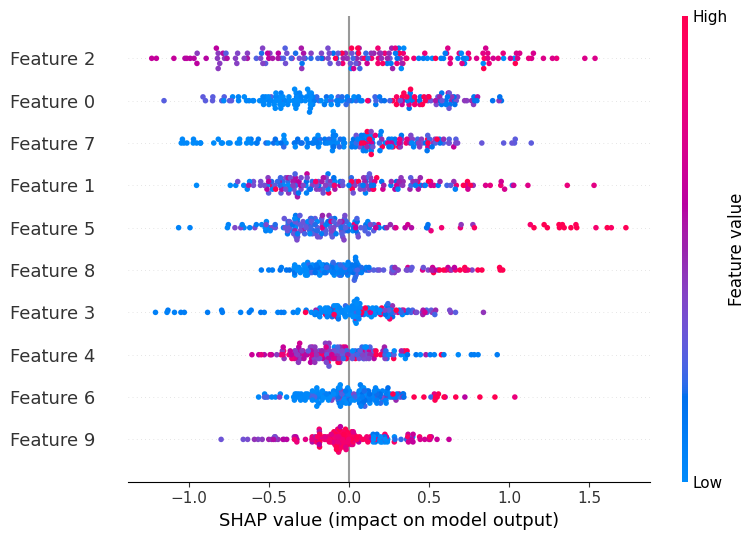

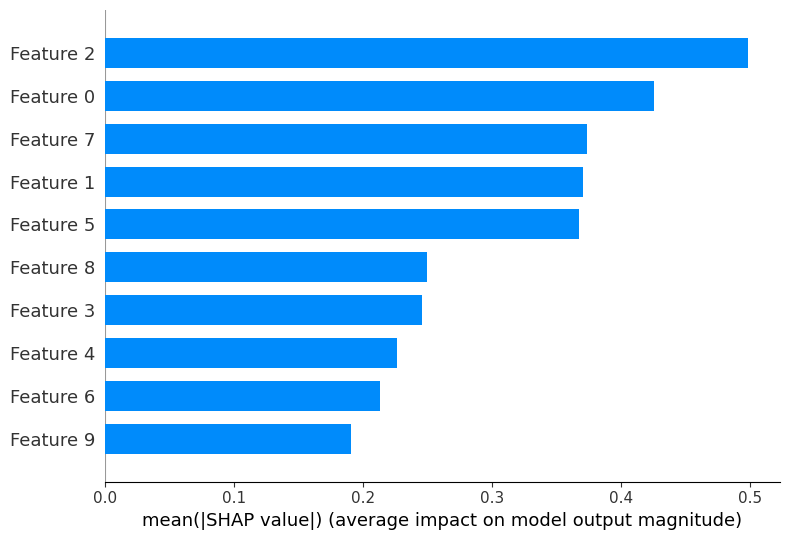

SHAP failed for XGBoost: 'numpy.ndarray' object has no attribute 'columns'

===== SHAP for CatBoost =====


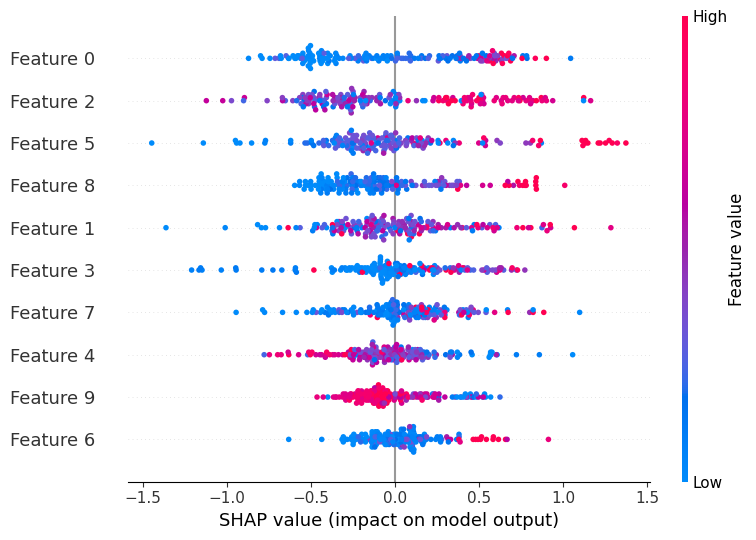

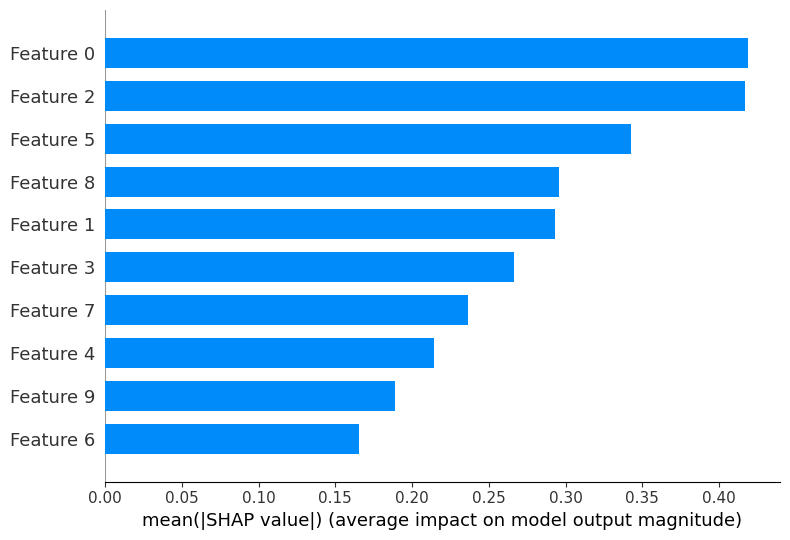

SHAP failed for CatBoost: 'numpy.ndarray' object has no attribute 'columns'

===== SHAP for RandomForest =====


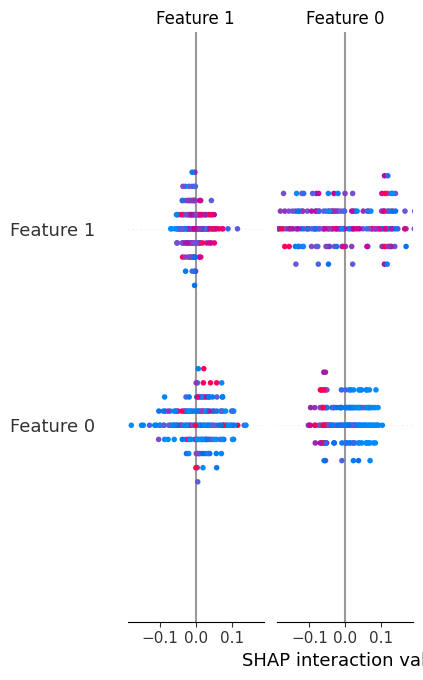

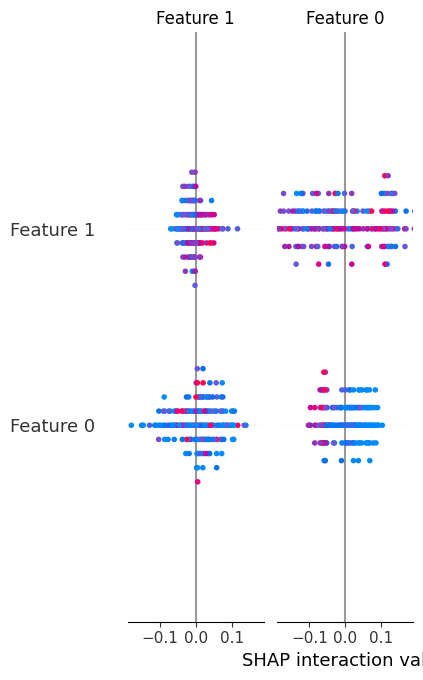

SHAP failed for RandomForest: 'numpy.ndarray' object has no attribute 'columns'


In [9]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def shap_analysis_multiple(models_dict, X_test, top_n=30):
    results = {}
    for name, model in models_dict.items():
        try:
            print(f"\n===== SHAP for {name} =====")
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            # If binary classification, take class 1
            if isinstance(shap_values, list):
                shap_values = shap_values[1]

            shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)
            shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

            importance_df = pd.DataFrame({
                "feature": X_test.columns,
                "mean_abs_shap": np.abs(shap_values).mean(axis=0)
            }).sort_values(by="mean_abs_shap", ascending=False)

            print(importance_df.head(top_n))
            results[name] = importance_df.head(top_n)

        except Exception as e:
            print(f"SHAP failed for {name}: {e}")
    return results

# Example run
shap_results = shap_analysis_multiple(models_dict, X_test)


In [1]:
import joblib
import pandas as pd

model = joblib.load("breast_cancer.joblib")

sample = pd.DataFrame([{
    "width_ratio": 1.40,
    "age_x_aspect": 84.0,
    "log_max_area": 7.78,
    "area_variability": 1224.0,
    "aspect_ratio": 1.50,
    "age_x_density": 38.67,
    "height_ratio": 1.43,
    "density_x_mean_area": 3.528,
    "elongation": 1.43,
    "size_consistency": 0.241
}])

print(model.predict(sample))
print(model.predict_proba(sample))


[0]
[[0.85497561 0.14502439]]
